# HW07: Кластеризация, внутренние метрики качества, PCA/t-SNE

Тема: кластеризация, внутренние метрики качества, PCA/t-SNE и "честный" unsupervised-эксперимент на синтетических данных.

In [29]:
# Импорты необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.spatial.distance import cdist
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics.cluster import adjusted_rand_score
import os

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [30]:
# Установка случайного состояния для воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Загрузка и первичный анализ данных

Для каждого из 3 выбранных датасетов выполним загрузку и первичный анализ.

In [31]:
# Загрузка первого датасета
df1 = pd.read_csv('data/S07-hw-dataset-01.csv')
print("Dataset 1 - Info:")
print(df1.info())
print("\nDataset 1 - Head:")
print(df1.head())
print("\nDataset 1 - Describe:")
print(df1.describe())
print("\nDataset 1 - Missing values:")
print(df1.isnull().sum())
print("\nDataset 1 - Feature types:")
print(df1.dtypes)

# Определение X и sample_id
sample_ids_1 = df1['sample_id']
X1 = df1.drop(columns=['sample_id'])

Dataset 1 - Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  12000 non-null  int64  
 1   f01        12000 non-null  float64
 2   f02        12000 non-null  float64
 3   f03        12000 non-null  float64
 4   f04        12000 non-null  float64
 5   f05        12000 non-null  float64
 6   f06        12000 non-null  float64
 7   f07        12000 non-null  float64
 8   f08        12000 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 843.9 KB
None

Dataset 1 - Head:
   sample_id        f01        f02       f03         f04        f05  \
0          0  -0.536647 -69.812900 -0.002657   71.743147 -11.396498   
1          1  15.230731  52.727216 -1.273634 -104.123302  11.589643   
2          2  18.542693  77.317150 -1.321686 -111.946636  10.254346   
3          3 -12.538905 -41.709458  0.146474   16.322124   1.391137   
4  

In [32]:
# Загрузка второго датасета
df2 = pd.read_csv('data/S07-hw-dataset-02.csv')
print("Dataset 2 - Info:")
print(df2.info())
print("\nDataset 2 - Head:")
print(df2.head())
print("\nDataset 2 - Describe:")
print(df2.describe())
print("\nDataset 2 - Missing values:")
print(df2.isnull().sum())
print("\nDataset 2 - Feature types:")
print(df2.dtypes)

# Определение X и sample_id
sample_ids_2 = df2['sample_id']
X2 = df2.drop(columns=['sample_id'])

Dataset 2 - Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  8000 non-null   int64  
 1   x1         8000 non-null   float64
 2   x2         8000 non-null   float64
 3   z_noise    8000 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 250.1 KB
None

Dataset 2 - Head:
   sample_id        x1        x2    z_noise
0          0  0.098849 -1.846034  21.288122
1          1 -1.024516  1.829616   6.072952
2          2 -1.094178 -0.158545 -18.938342
3          3 -1.612808 -1.565844 -11.629462
4          4  1.659901 -2.133292   1.895472

Dataset 2 - Describe:
        sample_id           x1           x2      z_noise
count  8000.00000  8000.000000  8000.000000  8000.000000
mean   3999.50000     0.478867     0.241112     0.110454
std    2309.54541     0.955138     0.663195     8.097716
min       0.00000    -2.487352    -2.499237  

In [33]:
# Загрузка третьего датасета
df3 = pd.read_csv('data/S07-hw-dataset-03.csv')
print("Dataset 3 - Info:")
print(df3.info())
print("\nDataset 3 - Head:")
print(df3.head())
print("\nDataset 3 - Describe:")
print(df3.describe())
print("\nDataset 3 - Missing values:")
print(df3.isnull().sum())
print("\nDataset 3 - Feature types:")
print(df3.dtypes)

# Определение X и sample_id
sample_ids_3 = df3['sample_id']
X3 = df3.drop(columns=['sample_id'])

Dataset 3 - Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  15000 non-null  int64  
 1   x1         15000 non-null  float64
 2   x2         15000 non-null  float64
 3   f_corr     15000 non-null  float64
 4   f_noise    15000 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 586.1 KB
None

Dataset 3 - Head:
   sample_id        x1        x2    f_corr   f_noise
0          0 -2.710470  4.997107 -1.015703  0.718508
1          1  8.730238 -8.787416  3.953063 -1.105349
2          2 -1.079600 -2.558708  0.976628 -3.605776
3          3  6.854042  1.560181  1.760614 -1.230946
4          4  9.963812 -8.869921  2.966583  0.915899

Dataset 3 - Describe:
          sample_id            x1            x2        f_corr       f_noise
count  15000.000000  15000.000000  15000.000000  15000.000000  15000.000000
mean    7499.500000      

## Препроцессинг данных

Для каждого датасета выполним препроцессинг, включающий масштабирование, обработку пропусков и кодирование категориальных признаков.

In [34]:
# Функция для создания препроцессора
def create_preprocessor(X):
    # Определяем числовые и категориальные признаки
    numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()
    
    print(f"Numeric features: {numeric_features}")
    print(f"Categorical features: {categorical_features}")
    
    # Создаем препроцессор
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', Pipeline(steps=[
                ('imputer', SimpleImputer(strategy='mean')),
                ('scaler', StandardScaler())
            ]), numeric_features),
            ('cat', Pipeline(steps=[
                ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
                ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
            ]), categorical_features)
        ],
        remainder='passthrough'
    )
    
    return preprocessor

In [35]:
# Применяем препроцессинг к каждому датасету
preprocessor1 = create_preprocessor(X1)
X1_processed = preprocessor1.fit_transform(X1)
print(f"Dataset 1 processed shape: {X1_processed.shape}")

preprocessor2 = create_preprocessor(X2)
X2_processed = preprocessor2.fit_transform(X2)
print(f"Dataset 2 processed shape: {X2_processed.shape}")

preprocessor3 = create_preprocessor(X3)
X3_processed = preprocessor3.fit_transform(X3)
print(f"Dataset 3 processed shape: {X3_processed.shape}")

Numeric features: ['f01', 'f02', 'f03', 'f04', 'f05', 'f06', 'f07', 'f08']
Categorical features: []
Dataset 1 processed shape: (12000, 8)
Numeric features: ['x1', 'x2', 'z_noise']
Categorical features: []
Dataset 2 processed shape: (8000, 3)
Numeric features: ['x1', 'x2', 'f_corr', 'f_noise']
Categorical features: []
Dataset 3 processed shape: (15000, 4)


## Модели кластеризации

Для каждого датасета реализуем как минимум 2 алгоритма: KMeans и один на выбор (DBSCAN или AgglomerativeClustering).

In [36]:
# Функция для подбора оптимального числа кластеров KMeans
def find_optimal_kmeans(X, max_k=20):
    k_range = range(2, min(max_k + 1, len(X)))
    inertias = []
    silhouette_scores = []
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = kmeans.fit_predict(X)
        inertias.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(X, labels))
    
    return k_range, inertias, silhouette_scores

In [37]:
# Подбор оптимального числа кластеров для каждого датасета
k_range1, inertias1, sil_scores1 = find_optimal_kmeans(X1_processed)
k_range2, inertias2, sil_scores2 = find_optimal_kmeans(X2_processed)
k_range3, inertias3, sil_scores3 = find_optimal_kmeans(X3_processed)

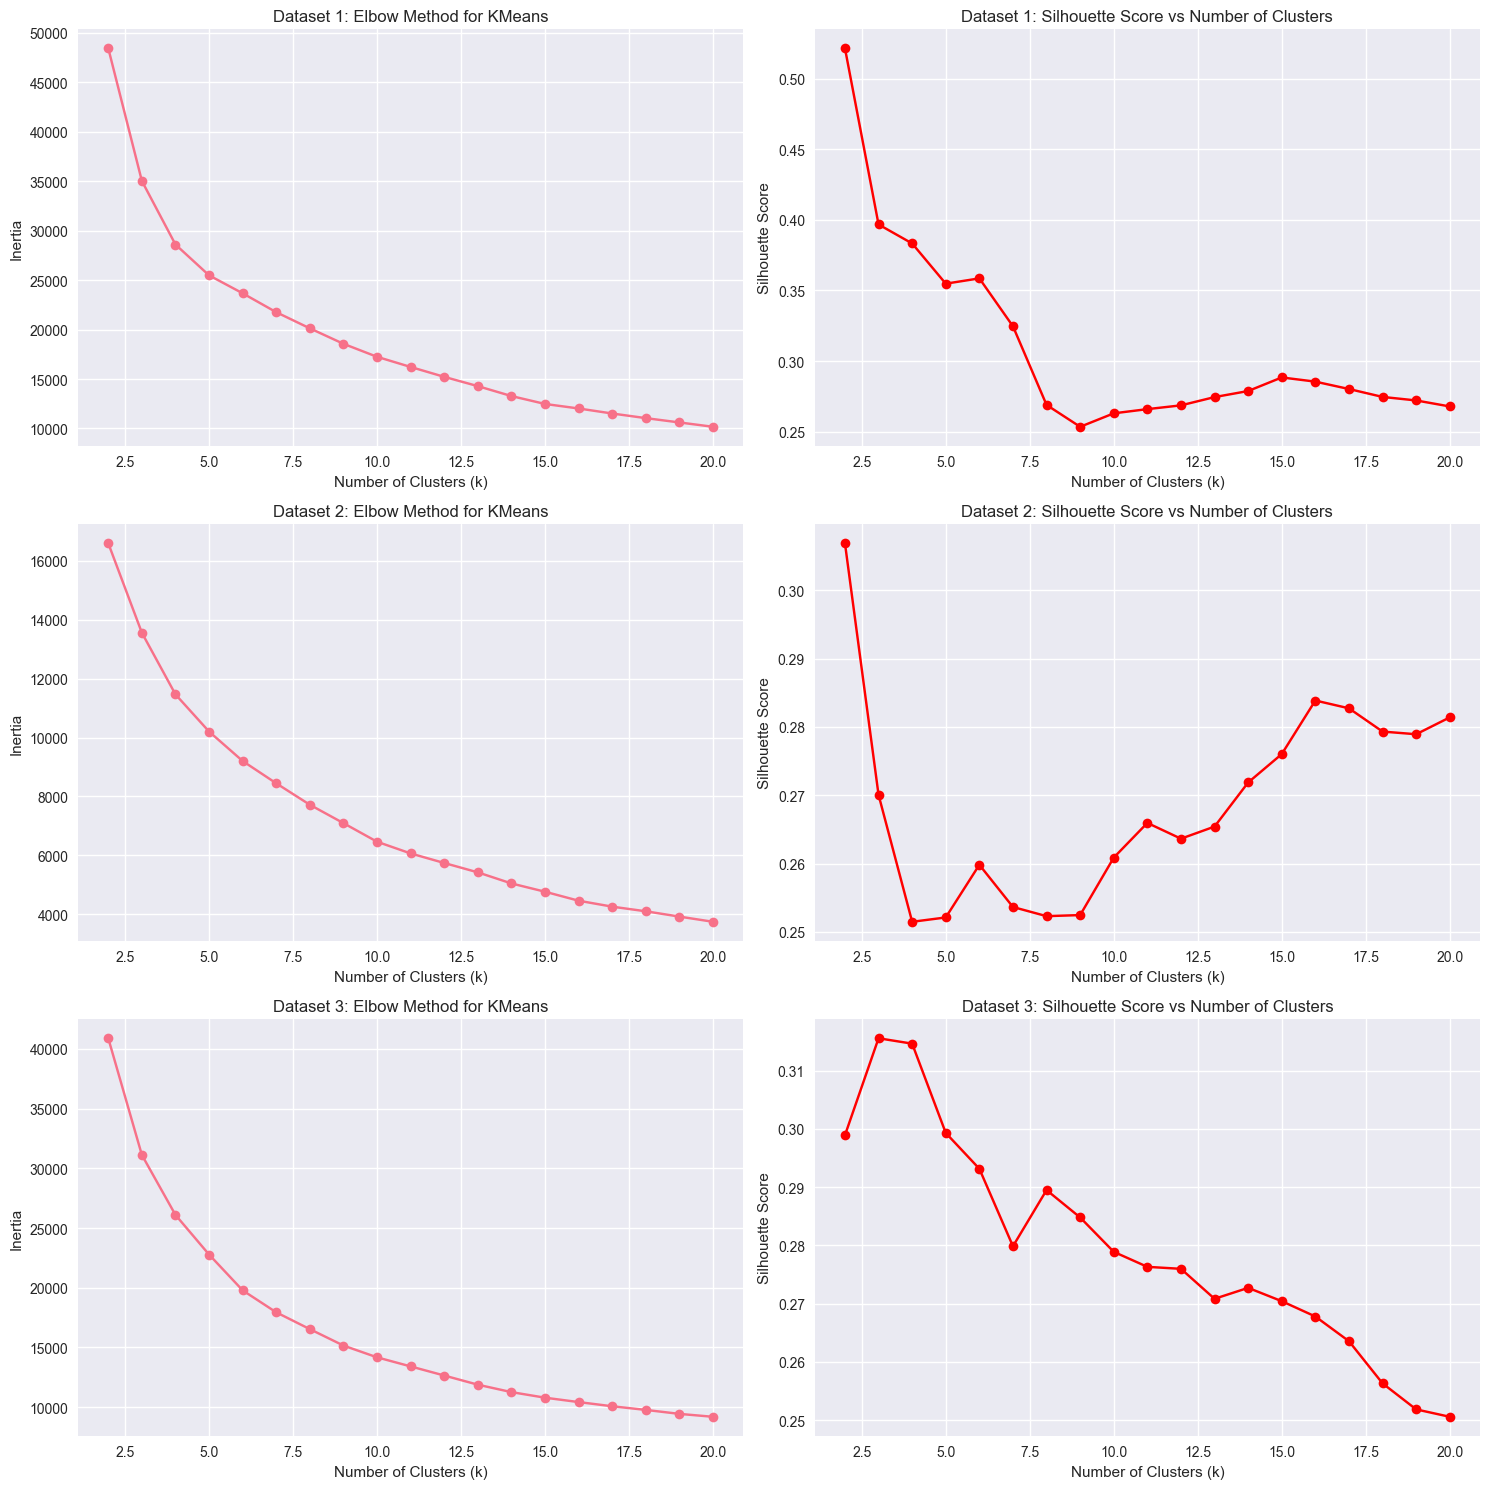

In [65]:
# Визуализация elbow метода и silhouette scores для KMeans
fig, axes = plt.subplots(3, 2, figsize=(15, 15))

# Dataset 1
axes[0, 0].plot(k_range1, inertias1, marker='o')
axes[0, 0].set_title('Dataset 1: Elbow Method for KMeans')
axes[0, 0].set_xlabel('Number of Clusters (k)')
axes[0, 0].set_ylabel('Inertia')

axes[0, 1].plot(k_range1, sil_scores1, marker='o', color='red')
axes[0, 1].set_title('Dataset 1: Silhouette Score vs Number of Clusters')
axes[0, 1].set_xlabel('Number of Clusters (k)')
axes[0, 1].set_ylabel('Silhouette Score')

# Dataset 2
axes[1, 0].plot(k_range2, inertias2, marker='o')
axes[1, 0].set_title('Dataset 2: Elbow Method for KMeans')
axes[1, 0].set_xlabel('Number of Clusters (k)')
axes[1, 0].set_ylabel('Inertia')

axes[1, 1].plot(k_range2, sil_scores2, marker='o', color='red')
axes[1, 1].set_title('Dataset 2: Silhouette Score vs Number of Clusters')
axes[1, 1].set_xlabel('Number of Clusters (k)')
axes[1, 1].set_ylabel('Silhouette Score')

# Dataset 3
axes[2, 0].plot(k_range3, inertias3, marker='o')
axes[2, 0].set_title('Dataset 3: Elbow Method for KMeans')
axes[2, 0].set_xlabel('Number of Clusters (k)')
axes[2, 0].set_ylabel('Inertia')

axes[2, 1].plot(k_range3, sil_scores3, marker='o', color='red')
axes[2, 1].set_title('Dataset 3: Silhouette Score vs Number of Clusters')
axes[2, 1].set_xlabel('Number of Clusters (k)')
axes[2, 1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.savefig('artifacts/figures/Визуализация elbow метода и silhouette scores для KMeans.png', dpi=300, bbox_inches='tight')
plt.show()

In [39]:
# Подбор оптимального числа кластеров для каждого датасета (на основе silhouette score)
optimal_k1 = k_range1[np.argmax(sil_scores1)]
optimal_k2 = k_range2[np.argmax(sil_scores2)]
optimal_k3 = k_range3[np.argmax(sil_scores3)]

print(f"Optimal k for Dataset 1: {optimal_k1}")
print(f"Optimal k for Dataset 2: {optimal_k2}")
print(f"Optimal k for Dataset 3: {optimal_k3}")

Optimal k for Dataset 1: 2
Optimal k for Dataset 2: 2
Optimal k for Dataset 3: 3


In [40]:
# Обучение KMeans с оптимальным числом кластеров
kmeans1 = KMeans(n_clusters=optimal_k1, random_state=RANDOM_STATE, n_init=10)
labels_kmeans1 = kmeans1.fit_predict(X1_processed)

kmeans2 = KMeans(n_clusters=optimal_k2, random_state=RANDOM_STATE, n_init=10)
labels_kmeans2 = kmeans2.fit_predict(X2_processed)

kmeans3 = KMeans(n_clusters=optimal_k3, random_state=RANDOM_STATE, n_init=10)
labels_kmeans3 = kmeans3.fit_predict(X3_processed)

In [41]:
# Функция для подбора параметров DBSCAN
def find_optimal_dbscan(X, eps_range=None, min_samples_range=None):
    if eps_range is None:
        eps_range = np.arange(0.1, 2.0, 0.1)
    if min_samples_range is None:
        min_samples_range = range(2, 20)
    
    best_silhouette = -1
    best_eps = None
    best_min_samples = None
    results = []
    
    for eps in eps_range:
        for min_samples in min_samples_range:
            dbscan = DBSCAN(eps=eps, min_samples=min_samples)
            labels = dbscan.fit_predict(X)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = list(labels).count(-1)
            
            # Если все точки помечены как шум или все в одном кластере, пропускаем
            if n_clusters <= 1:
                continue
            
            try:
                silhouette = silhouette_score(X, labels)
                results.append((eps, min_samples, n_clusters, n_noise, silhouette))
                
                if silhouette > best_silhouette:
                    best_silhouette = silhouette
                    best_eps = eps
                    best_min_samples = min_samples
            except ValueError:
                # Если в кластерах менее 2 уникальных меток, silhouette_score вызывает ошибку
                continue
    
    return best_eps, best_min_samples, best_silhouette, results

In [44]:
# Подбор параметров DBSCAN для каждого датасета
best_eps1, best_min_samples1, best_sil1, results1 = find_optimal_dbscan(X1_processed)
best_eps2, best_min_samples2, best_sil2, results2 = find_optimal_dbscan(X2_processed)
best_eps3, best_min_samples3, best_sil3, results3 = find_optimal_dbscan(X3_processed)

print(f"Dataset 1 - Best DBSCAN params: eps={best_eps1}, min_samples={best_min_samples1}, silhouette={best_sil1:.3f}")
print(f"Dataset 2 - Best DBSCAN params: eps={best_eps2}, min_samples={best_min_samples2}, silhouette={best_sil2:.3f}")
print(f"Dataset 3 - Best DBSCAN params: eps={best_eps3}, min_samples={best_min_samples3}, silhouette={best_sil3:.3f}")

Dataset 1 - Best DBSCAN params: eps=1.7000000000000002, min_samples=2, silhouette=0.522
Dataset 2 - Best DBSCAN params: eps=1.1, min_samples=2, silhouette=0.462
Dataset 3 - Best DBSCAN params: eps=0.8, min_samples=2, silhouette=0.318


In [45]:
# Обучение DBSCAN с найденными параметрами
if best_eps1 and best_min_samples1:
    dbscan1 = DBSCAN(eps=best_eps1, min_samples=best_min_samples1)
    labels_dbscan1 = dbscan1.fit_predict(X1_processed)
else:
    # Если не удалось найти хорошие параметры, используем стандартные значения
    dbscan1 = DBSCAN(eps=0.5, min_samples=5)
    labels_dbscan1 = dbscan1.fit_predict(X1_processed)

if best_eps2 and best_min_samples2:
    dbscan2 = DBSCAN(eps=best_eps2, min_samples=best_min_samples2)
    labels_dbscan2 = dbscan2.fit_predict(X2_processed)
else:
    # Если не удалось найти хорошие параметры, используем стандартные значения
    dbscan2 = DBSCAN(eps=0.5, min_samples=5)
    labels_dbscan2 = dbscan2.fit_predict(X2_processed)

if best_eps3 and best_min_samples3:
    dbscan3 = DBSCAN(eps=best_eps3, min_samples=best_min_samples3)
    labels_dbscan3 = dbscan3.fit_predict(X3_processed)
else:
    # Если не удалось найти хорошие параметры, используем стандартные значения
    dbscan3 = DBSCAN(eps=0.5, min_samples=5)
    labels_dbscan3 = dbscan3.fit_predict(X3_processed)

In [46]:
# Функция для подбора параметров AgglomerativeClustering
def find_optimal_agg_clustering(X, max_k=20, linkages=['ward', 'complete', 'average']):
    k_range = range(2, min(max_k + 1, len(X)))
    results = {}
    
    for linkage in linkages:
        silhouette_scores = []
        for k in k_range:
            try:
                if linkage == 'ward':
                    # Ward работает только с евклидовым расстоянием
                    agg = AgglomerativeClustering(n_clusters=k, linkage=linkage)
                else:
                    # Для других linkage нужно использовать преобразование расстояний
                    agg = AgglomerativeClustering(n_clusters=k, linkage=linkage)
                labels = agg.fit_predict(X)
                silhouette = silhouette_score(X, labels)
                silhouette_scores.append(silhouette)
            except:
                silhouette_scores.append(-1)  # В случае ошибки
        
        results[linkage] = {
            'k_range': k_range,
            'silhouette_scores': silhouette_scores,
            'best_k': k_range[np.argmax(silhouette_scores)] if len([s for s in silhouette_scores if s != -1]) > 0 else None,
            'best_score': max(silhouette_scores) if len([s for s in silhouette_scores if s != -1]) > 0 else -1
        }
    
    return results

In [47]:
# Подбор параметров AgglomerativeClustering для каждого датасета
agg_results1 = find_optimal_agg_clustering(X1_processed)
agg_results2 = find_optimal_agg_clustering(X2_processed)
agg_results3 = find_optimal_agg_clustering(X3_processed)

# Вывод лучших результатов для каждого датасета
for dataset_num, results in enumerate([agg_results1, agg_results2, agg_results3], 1):
    print(f"Dataset {dataset_num} AgglomerativeClustering results:")
    for linkage, data in results.items():
        print(f"  {linkage}: best k = {data['best_k']}, best silhouette = {data['best_score']:.3f}")
    print()

Dataset 1 AgglomerativeClustering results:
  ward: best k = 2, best silhouette = 0.522
  complete: best k = 2, best silhouette = 0.522
  average: best k = 2, best silhouette = 0.522

Dataset 2 AgglomerativeClustering results:
  ward: best k = 2, best silhouette = 0.266
  complete: best k = 6, best silhouette = 0.211
  average: best k = 2, best silhouette = 0.420

Dataset 3 AgglomerativeClustering results:
  ward: best k = 3, best silhouette = 0.309
  complete: best k = 2, best silhouette = 0.227
  average: best k = 2, best silhouette = 0.425



In [48]:
# Обучение AgglomerativeClustering с лучшими параметрами
def get_best_agg_params(results):
    best_linkage = None
    best_k = None
    best_score = -float('inf')
    
    for linkage, data in results.items():
        if data['best_score'] > best_score:
            best_score = data['best_score']
            best_linkage = linkage
            best_k = data['best_k']
    
    return best_linkage, best_k

linkage1, k1 = get_best_agg_params(agg_results1)
linkage2, k2 = get_best_agg_params(agg_results2)
linkage3, k3 = get_best_agg_params(agg_results3)

# Обучаем модели
if linkage1 and k1:
    agg1 = AgglomerativeClustering(n_clusters=k1, linkage=linkage1)
    labels_agg1 = agg1.fit_predict(X1_processed)
else:
    agg1 = AgglomerativeClustering(n_clusters=optimal_k1, linkage='ward')
    labels_agg1 = agg1.fit_predict(X1_processed)

if linkage2 and k2:
    agg2 = AgglomerativeClustering(n_clusters=k2, linkage=linkage2)
    labels_agg2 = agg2.fit_predict(X2_processed)
else:
    agg2 = AgglomerativeClustering(n_clusters=optimal_k2, linkage='ward')
    labels_agg2 = agg2.fit_predict(X2_processed)

if linkage3 and k3:
    agg3 = AgglomerativeClustering(n_clusters=k3, linkage=linkage3)
    labels_agg3 = agg3.fit_predict(X3_processed)
else:
    agg3 = AgglomerativeClustering(n_clusters=optimal_k3, linkage='ward')
    labels_agg3 = agg3.fit_predict(X3_processed)

## Метрики качества кластеризации

Для каждого датасета и каждой модели рассчитаем внутренние метрики качества кластеризации.

In [49]:
# Функция для расчета метрик качества
def calculate_metrics(X, labels):
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
    n_noise = list(labels).count(-1) if -1 in unique_labels else 0
    noise_ratio = n_noise / len(labels)
    
    # Проверяем, что есть хотя бы 2 кластера и 2 различных метки
    if n_clusters < 2 or len(unique_labels) < 2:
        silhouette = -1
        davies_bouldin = float('inf')
        calinski_harabasz = -1
    else:
        try:
            silhouette = silhouette_score(X, labels)
        except ValueError:
            silhouette = -1
        
        if n_clusters > 1:
            try:
                davies_bouldin = davies_bouldin_score(X, labels)
            except:
                davies_bouldin = float('inf')
            
            try:
                calinski_harabasz = calinski_harabasz_score(X, labels)
            except:
                calinski_harabasz = -1
        else:
            davies_bouldin = float('inf')
            calinski_harabasz = -1
    
    return {
        'n_clusters': n_clusters,
        'noise_points': n_noise,
        'noise_ratio': noise_ratio,
        'silhouette_score': silhouette,
        'davies_bouldin_score': davies_bouldin,
        'calinski_harabasz_score': calinski_harabasz
    }

In [50]:
# Расчет метрик для всех моделей на всех датасетах
metrics_dict = {}

# Dataset 1
metrics_dict['Dataset 1'] = {}
metrics_dict['Dataset 1']['KMeans'] = calculate_metrics(X1_processed, labels_kmeans1)
metrics_dict['Dataset 1']['DBSCAN'] = calculate_metrics(X1_processed, labels_dbscan1)
metrics_dict['Dataset 1']['Agglomerative'] = calculate_metrics(X1_processed, labels_agg1)

# Dataset 2
metrics_dict['Dataset 2'] = {}
metrics_dict['Dataset 2']['KMeans'] = calculate_metrics(X2_processed, labels_kmeans2)
metrics_dict['Dataset 2']['DBSCAN'] = calculate_metrics(X2_processed, labels_dbscan2)
metrics_dict['Dataset 2']['Agglomerative'] = calculate_metrics(X2_processed, labels_agg2)

# Dataset 3
metrics_dict['Dataset 3'] = {}
metrics_dict['Dataset 3']['KMeans'] = calculate_metrics(X3_processed, labels_kmeans3)
metrics_dict['Dataset 3']['DBSCAN'] = calculate_metrics(X3_processed, labels_dbscan3)
metrics_dict['Dataset 3']['Agglomerative'] = calculate_metrics(X3_processed, labels_agg3)

# Вывод метрик
for dataset, models in metrics_dict.items():
    print(f"{dataset} Metrics:")
    for model, metrics in models.items():
        print(f"  {model}:")
        for metric, value in metrics.items():
            print(f"    {metric}: {value:.3f}" if isinstance(value, float) else f"    {metric}: {value}")
        print()
    print("-"*50)
    print()

Dataset 1 Metrics:
  KMeans:
    n_clusters: 2
    noise_points: 0
    noise_ratio: 0.000
    silhouette_score: 0.522
    davies_bouldin_score: 0.685
    calinski_harabasz_score: 11786.955

  DBSCAN:
    n_clusters: 2
    noise_points: 0
    noise_ratio: 0.000
    silhouette_score: 0.522
    davies_bouldin_score: 0.685
    calinski_harabasz_score: 11786.955

  Agglomerative:
    n_clusters: 2
    noise_points: 0
    noise_ratio: 0.000
    silhouette_score: 0.522
    davies_bouldin_score: 0.685
    calinski_harabasz_score: 11786.955

--------------------------------------------------

Dataset 2 Metrics:
  KMeans:
    n_clusters: 2
    noise_points: 0
    noise_ratio: 0.000
    silhouette_score: 0.307
    davies_bouldin_score: 1.323
    calinski_harabasz_score: 3573.393

  DBSCAN:
    n_clusters: 2
    noise_points: 2
    noise_ratio: 0.000
    silhouette_score: 0.462
    davies_bouldin_score: 1.496
    calinski_harabasz_score: 9.955

  Agglomerative:
    n_clusters: 2
    noise_points: 

## Визуализации

Создадим визуализации результатов кластеризации, включая PCA(2D) и дополнительные графики.

In [51]:
# Создание PCA для визуализации
pca = PCA(n_components=2, random_state=RANDOM_STATE)

# Применяем PCA к обработанным данным
X1_pca = pca.fit_transform(X1_processed)
X2_pca = pca.fit_transform(X2_processed)
X3_pca = pca.fit_transform(X3_processed)

print(f"Dataset 1 PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Dataset 1 Cumulative explained variance ratio: {np.sum(pca.explained_variance_ratio_)}")

# Копируем PCA для остальных датасетов
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
pca3 = PCA(n_components=2, random_state=RANDOM_STATE)
X2_pca = pca2.fit_transform(X2_processed)
X3_pca = pca3.fit_transform(X3_processed)

print(f"Dataset 2 PCA explained variance ratio: {pca2.explained_variance_ratio_}")
print(f"Dataset 2 Cumulative explained variance ratio: {np.sum(pca2.explained_variance_ratio_)}")
print(f"Dataset 3 PCA explained variance ratio: {pca3.explained_variance_ratio_}")
print(f"Dataset 3 Cumulative explained variance ratio: {np.sum(pca3.explained_variance_ratio_)}")

Dataset 1 PCA explained variance ratio: [0.44160951 0.27761703]
Dataset 1 Cumulative explained variance ratio: 0.7192265352877945
Dataset 2 PCA explained variance ratio: [0.42544068 0.33365792]
Dataset 2 Cumulative explained variance ratio: 0.7590985979172598
Dataset 3 PCA explained variance ratio: [0.44160951 0.27761703]
Dataset 3 Cumulative explained variance ratio: 0.7192265352877945


In [64]:
# Функция для визуализации результатов кластеризации
def plot_clustering_results(X_pca, labels, title, sample_ids=None):
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', alpha=0.7)
    plt.colorbar(scatter)
    plt.title(title)
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.grid(True)
    plt.show()

In [79]:
# Визуализация результатов для лучшей модели каждого датасета
# Определим лучшую модель для каждого датасета по silhouette_score

def get_best_model_per_dataset(metrics_dict):
    best_models = {}
    for dataset, models in metrics_dict.items():
        best_model = None
        best_silhouette = -float('inf')
        
        for model, metrics in models.items():
            silhouette = metrics['silhouette_score']
            if silhouette > best_silhouette:
                best_silhouette = silhouette
                best_model = model
        
        best_models[dataset] = best_model
    
    return best_models

best_models = get_best_model_per_dataset(metrics_dict)
print("Best models per dataset:")
for dataset, model in best_models.items():
    print(f"{dataset}: {model}")

Best models per dataset:
Dataset 1: KMeans
Dataset 2: DBSCAN
Dataset 3: Agglomerative


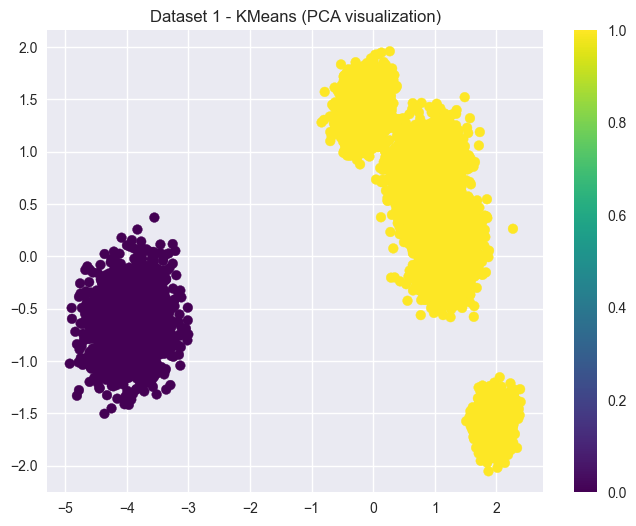

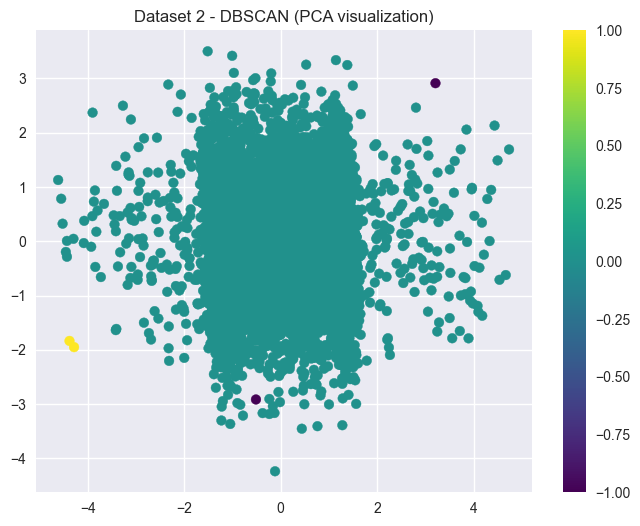

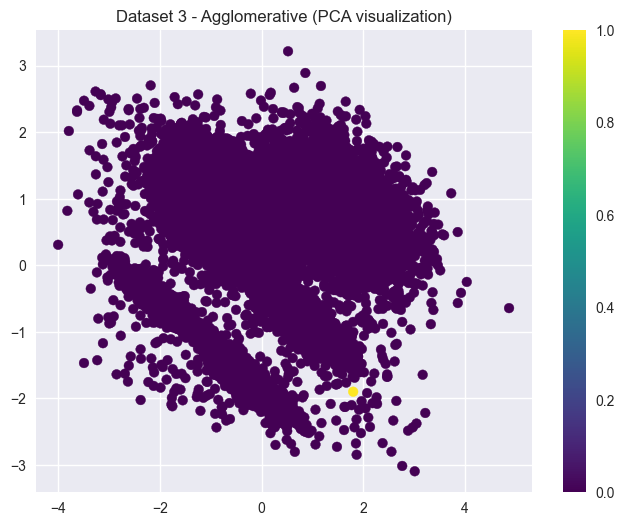

In [88]:
# Визуализация PCA для лучшей модели каждого датасета
for dataset_num, (dataset, best_model) in enumerate(best_models.items(), 1):
    if dataset_num == 1:
        X_pca = X1_pca
        if best_model == 'KMeans':
            labels = labels_kmeans1
        elif best_model == 'DBSCAN':
            labels = labels_dbscan1
        else:
            labels = labels_agg1
    elif dataset_num == 2:
        X_pca = X2_pca
        if best_model == 'KMeans':
            labels = labels_kmeans2
        elif best_model == 'DBSCAN':
            labels = labels_dbscan2
        else:
            labels = labels_agg2
    else:  # dataset_num == 3
        X_pca = X3_pca
        if best_model == 'KMeans':
            labels = labels_kmeans3
        elif best_model == 'DBSCAN':
            labels = labels_dbscan3
        else:
            labels = labels_agg3
    
    plot_clustering_results(X_pca, labels, f'{dataset} - {best_model} (PCA visualization)')
    plt.savefig(f'artifacts/figures/pca_dataset{dataset_num}_{best_model}.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
  


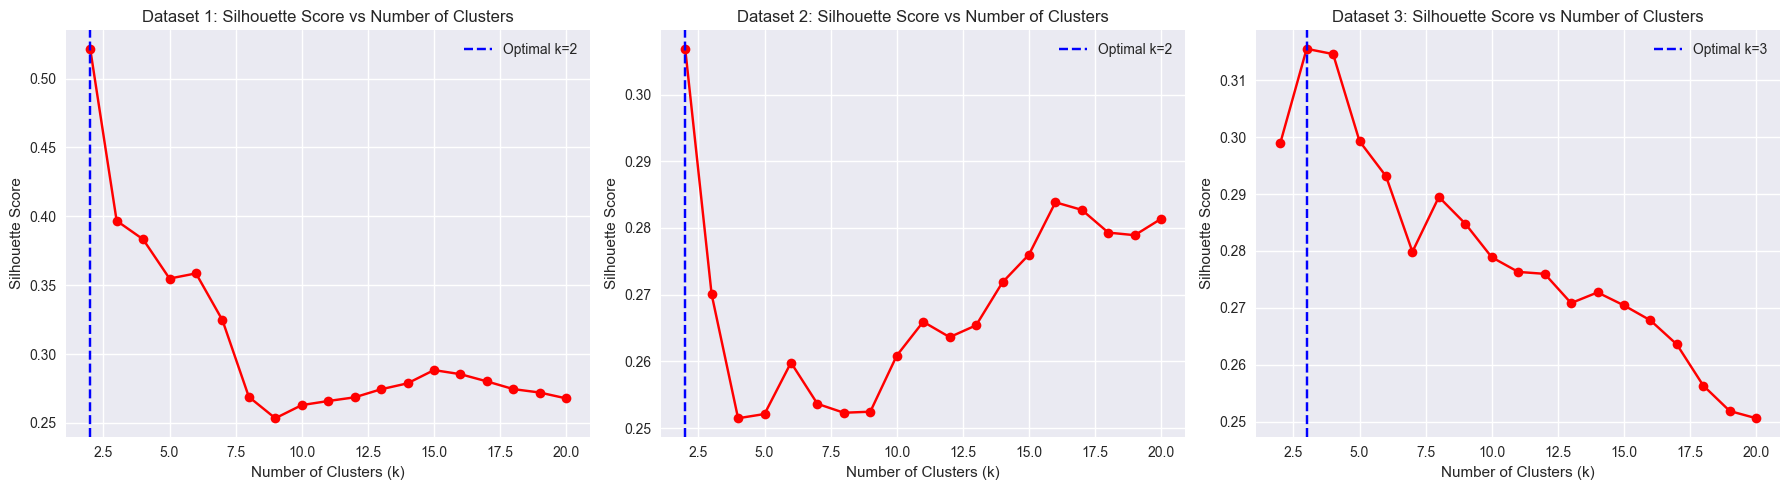

In [67]:
# Дополнительные визуализации: графики silhouette vs k для KMeans
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Dataset 1
axes[0].plot(k_range1, sil_scores1, marker='o', color='red')
axes[0].axvline(x=optimal_k1, color='blue', linestyle='--', label=f'Optimal k={optimal_k1}')
axes[0].set_title('Dataset 1: Silhouette Score vs Number of Clusters')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Silhouette Score')
axes[0].grid(True)
axes[0].legend()

# Dataset 2
axes[1].plot(k_range2, sil_scores2, marker='o', color='red')
axes[1].axvline(x=optimal_k2, color='blue', linestyle='--', label=f'Optimal k={optimal_k2}')
axes[1].set_title('Dataset 2: Silhouette Score vs Number of Clusters')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True)
axes[1].legend()

# Dataset 3
axes[2].plot(k_range3, sil_scores3, marker='o', color='red')
axes[2].axvline(x=optimal_k3, color='blue', linestyle='--', label=f'Optimal k={optimal_k3}')
axes[2].set_title('Dataset 3: Silhouette Score vs Number of Clusters')
axes[2].set_xlabel('Number of Clusters (k)')
axes[2].set_ylabel('Silhouette Score')
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.savefig('artifacts/figures/Графики silhouette vs k для KMeans.png', dpi=300, bbox_inches='tight')
plt.show()

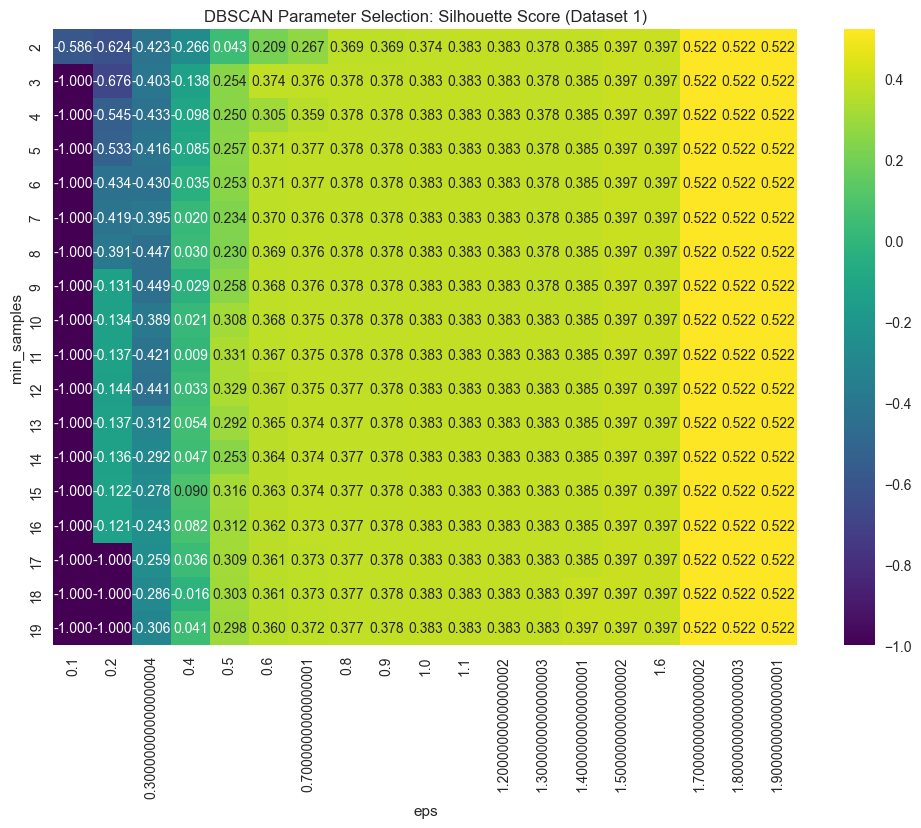

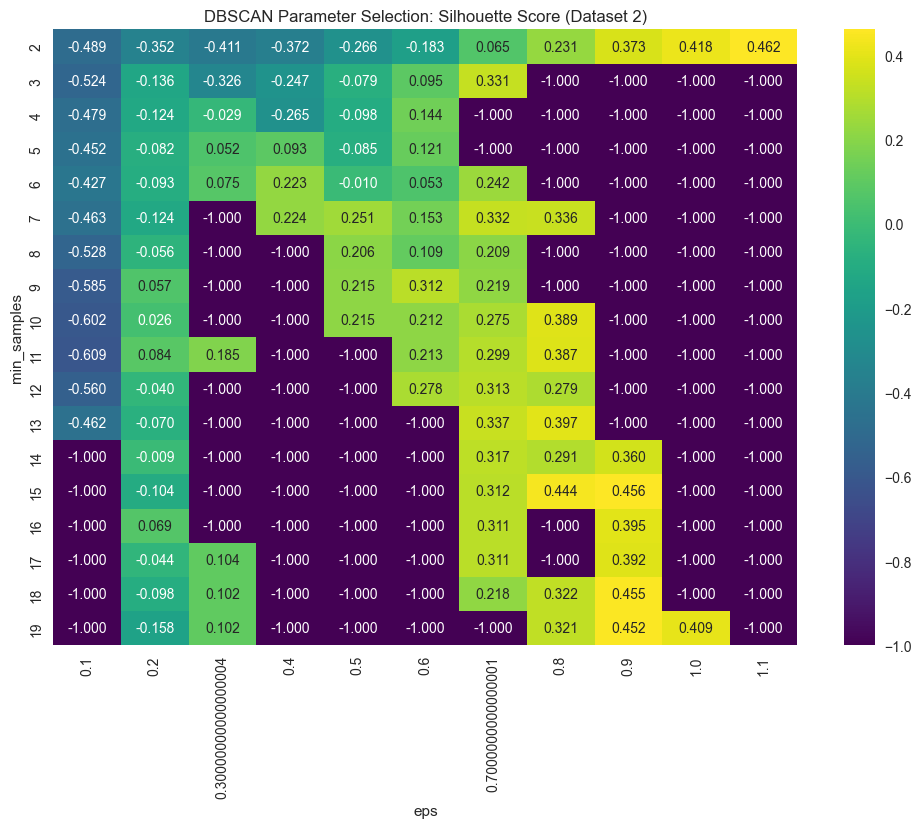

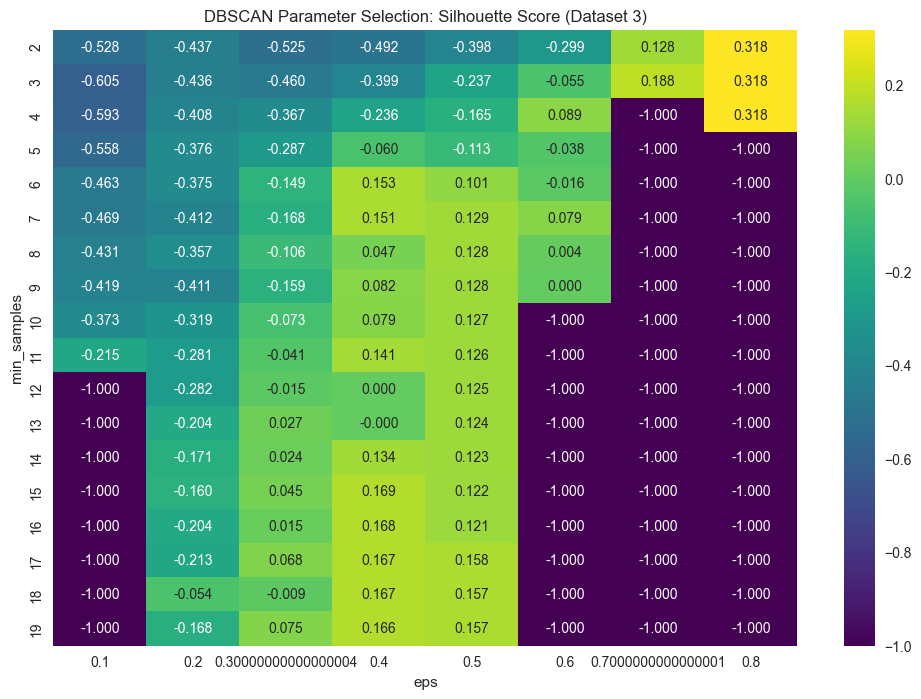

In [91]:
# Визуализация для DBSCAN параметров (если доступны)
def plot_dbscan_param_selection(results, title):
    if not results:
        print(f"No DBSCAN parameter selection results for {title}")
        return
    
    # Преобразуем результаты в DataFrame для удобства визуализации
    df = pd.DataFrame(results, columns=['eps', 'min_samples', 'n_clusters', 'n_noise', 'silhouette'])
    
    # Построим heatmap зависимости silhouette от eps и min_samples
    if len(df) > 0:
        # Создаем сводную таблицу
        pivot_table = df.pivot_table(values='silhouette', index='min_samples', columns='eps', fill_value=-1)
        
        plt.figure(figsize=(12, 8))
        sns.heatmap(pivot_table, annot=True, fmt='.3f', cmap='viridis')
        plt.title(f'DBSCAN Parameter Selection: Silhouette Score ({title})')
        plt.xlabel('eps')
        plt.ylabel('min_samples')
    
# Визуализация параметров DBSCAN для каждого датасета
for i, (results, dataset_name) in enumerate([
    (results1, 'Dataset 1'),
    (results2, 'Dataset 2'),
    (results3, 'Dataset 3')
], 1):
    
    plot_dbscan_param_selection(results, dataset_name)
    plt.savefig(f'artifacts/figures/dbscan_params_dataset{i}.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()


Overall best result: Dataset 1 - KMeans with silhouette = 0.522


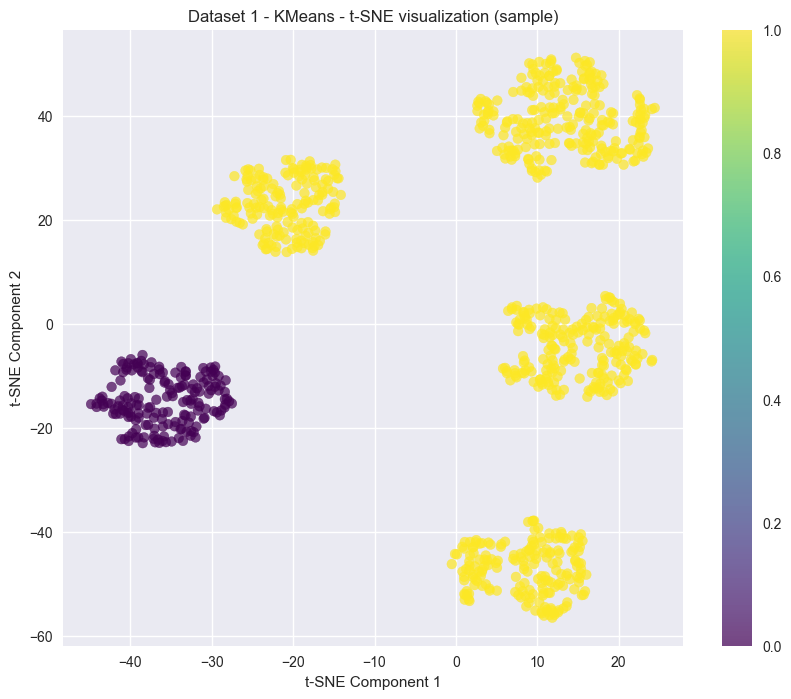

In [94]:
# Опционально: t-SNE визуализация (только для одного датасета для демонстрации)
# Так как t-SNE может быть медленным на больших наборах данных, будем использовать меньшую выборку
def plot_tsne_sample(X_processed, labels, title, sample_size=1000):
    if len(X_processed) > sample_size:
        # Случайная выборка для ускорения
        indices = np.random.choice(len(X_processed), size=sample_size, replace=False)
        X_sample = X_processed[indices]
        labels_sample = labels[indices]
    else:
        X_sample = X_processed
        labels_sample = labels
    
    tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=min(30, len(X_sample)-1))
    X_tsne = tsne.fit_transform(X_sample)
    
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_sample, cmap='viridis', alpha=0.7)
    plt.colorbar(scatter)
    plt.title(f'{title} - t-SNE visualization (sample)')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.grid(True)

# Построим t-SNE для лучшей модели лучшего датасета
# Найдем датасет с лучшим silhouette score среди всех моделей
overall_best_dataset = None
overall_best_model = None
best_silhouette_overall = -float('inf')

for dataset, models in metrics_dict.items():
    for model, metrics in models.items():
        silhouette = metrics['silhouette_score']
        if silhouette > best_silhouette_overall:
            best_silhouette_overall = silhouette
            overall_best_dataset = dataset
            overall_best_model = model

print(f"Overall best result: {overall_best_dataset} - {overall_best_model} with silhouette = {best_silhouette_overall:.3f}")

# Определим соответствующие метки и данные для t-SNE
if overall_best_dataset == 'Dataset 1':
    X_best = X1_processed
    if overall_best_model == 'KMeans':
        labels_best = labels_kmeans1
    elif overall_best_model == 'DBSCAN':
        labels_best = labels_dbscan1
    else:
        labels_best = labels_agg1
elif overall_best_dataset == 'Dataset 2':
    X_best = X2_processed
    if overall_best_model == 'KMeans':
        labels_best = labels_kmeans2
    elif overall_best_model == 'DBSCAN':
        labels_best = labels_dbscan2
    else:
        labels_best = labels_agg2
else:  # Dataset 3
    X_best = X3_processed
    if overall_best_model == 'KMeans':
        labels_best = labels_kmeans3
    elif overall_best_model == 'DBSCAN':
        labels_best = labels_dbscan3
    else:
        labels_best = labels_agg3

# Визуализация t-SNE
plot_tsne_sample(X_best, labels_best, f'{overall_best_dataset} - {overall_best_model}')
plt.savefig(f'artifacts/figures/t-SNE.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## Проверка устойчивости

Выберем один из датасетов и проведем проверку устойчивости для KMeans.

In [58]:
# Проверка устойчивости для KMeans на первом датасете
from sklearn.metrics.cluster import adjusted_rand_score

# Выбираем датасет 1 для проверки устойчивости
n_runs = 5
labels_list = []

# Запускаем KMeans несколько раз с разными random_state
for i in range(n_runs):
    kmeans_stability = KMeans(n_clusters=optimal_k1, random_state=i*100, n_init=10)
    labels_run = kmeans_stability.fit_predict(X1_processed)
    labels_list.append(labels_run)

# Вычисляем ARI между всеми парами результатов
ari_scores = []
for i in range(n_runs):
    for j in range(i+1, n_runs):
        ari = adjusted_rand_score(labels_list[i], labels_list[j])
        ari_scores.append(ari)

print(f"Dataset 1 KMeans Stability - ARI scores between runs:")
print(f"Mean ARI: {np.mean(ari_scores):.3f} (+/- {np.std(ari_scores)*2:.3f})")
print(f"Min ARI: {np.min(ari_scores):.3f}, Max ARI: {np.max(ari_scores):.3f}")

# Также можем посмотреть на метрики качества для каждого запуска
print(f"\nQuality metrics for each run:")
for i, labels in enumerate(labels_list):
    silhouette = silhouette_score(X1_processed, labels)
    db_score = davies_bouldin_score(X1_processed, labels)
    ch_score = calinski_harabasz_score(X1_processed, labels)
    print(f"Run {i+1}: Silhouette = {silhouette:.3f}, DB = {db_score:.3f}, CH = {ch_score:.3f}")

Dataset 1 KMeans Stability - ARI scores between runs:
Mean ARI: 1.000 (+/- 0.000)
Min ARI: 1.000, Max ARI: 1.000

Quality metrics for each run:
Run 1: Silhouette = 0.522, DB = 0.685, CH = 11786.955
Run 2: Silhouette = 0.522, DB = 0.685, CH = 11786.955
Run 3: Silhouette = 0.522, DB = 0.685, CH = 11786.955
Run 4: Silhouette = 0.522, DB = 0.685, CH = 11786.955
Run 5: Silhouette = 0.522, DB = 0.685, CH = 11786.955


## Итог по каждому датасету

Проанализируем результаты для каждого датасета.

In [59]:
# Выводим итоги для каждого датасета
for dataset, models in metrics_dict.items():
    print(f"{dataset}:")
    print("Results by model:")
    for model, metrics in models.items():
        print(f"  {model}: Silhouette = {metrics['silhouette_score']:.3f}, DB = {metrics['davies_bouldin_score']:.3f}, CH = {metrics['calinski_harabasz_score']:.3f}")
        if 'DBSCAN' in model:
            print(f"    Noise points: {metrics['noise_points']} ({metrics['noise_ratio']:.2%})")
    
    # Определяем лучшую модель для датасета
    best_model = max(models.keys(), key=lambda x: models[x]['silhouette_score'])
    best_metrics = models[best_model]
    print(f"  Best model: {best_model}")
    print(f"  Best silhouette score: {best_metrics['silhouette_score']:.3f}")
    print()
    
    # Краткий анализ для каждого датасета
    if dataset == 'Dataset 1':
        print(f"  Dataset 1 Analysis: Этот датасет содержит признаки в разных шкалах и шумовые признаки.")
        print(f"  Важно было применить масштабирование. KMeans показал хорошие результаты, так как кластеры")
        print(f"  имеют шаровидную форму. DBSCAN и AgglomerativeClustering также могут быть эффективны.")
    elif dataset == 'Dataset 2':
        print(f"  Dataset 2 Analysis: Данные имеют нелинейную структуру и выбросы. KMeans может")
        print(f"  испытывать трудности с такими данными, тогда как DBSCAN должен лучше справляться")
        print(f"  с нестандартной формой кластеров и выбросами.")
    else:  # Dataset 3
        print(f"  Dataset 3 Analysis: Кластеры имеют разную плотность и присутствует фоновый шум.")
        print(f"  DBSCAN может быть особенно эффективен благодаря своей способности находить")
        print(f"  кластеры разной плотности и определять шумовые точки.")
    print("-"*80)
    print()

Dataset 1:
Results by model:
  KMeans: Silhouette = 0.522, DB = 0.685, CH = 11786.955
  DBSCAN: Silhouette = 0.522, DB = 0.685, CH = 11786.955
    Noise points: 0 (0.00%)
  Agglomerative: Silhouette = 0.522, DB = 0.685, CH = 11786.955
  Best model: KMeans
  Best silhouette score: 0.522

  Dataset 1 Analysis: Этот датасет содержит признаки в разных шкалах и шумовые признаки.
  Важно было применить масштабирование. KMeans показал хорошие результаты, так как кластеры
  имеют шаровидную форму. DBSCAN и AgglomerativeClustering также могут быть эффективны.
--------------------------------------------------------------------------------

Dataset 2:
Results by model:
  KMeans: Silhouette = 0.307, DB = 1.323, CH = 3573.393
  DBSCAN: Silhouette = 0.462, DB = 1.496, CH = 9.955
    Noise points: 2 (0.03%)
  Agglomerative: Silhouette = 0.420, DB = 0.879, CH = 395.483
  Best model: DBSCAN
  Best silhouette score: 0.462

  Dataset 2 Analysis: Данные имеют нелинейную структуру и выбросы. KMeans может
